In [1]:
import sys
assert sys.version.split('.')[0] == '3'

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2

In [25]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

from smanmi import abase, audio, effects as E, hotplug, midi, logic as L, signals as S, state, util
from nuru import features, settings

# Library

## primitives

In [55]:
dict(a=1).update

{'a': 1}

In [69]:
def plot_sigs(d, sigs, names):
    sr = L.SignalRunner(d)
    data = {name: [] for name in names}
    for sig in sigs:
        sig = sr(**sig)
        for name in names:
            data[name].append(sig[name])

    for name in names:
        plt.plot(data[name], label=name)
    plt.legend()


In [72]:
from audioset import mel_features

mel_features.hertz_to_mel()

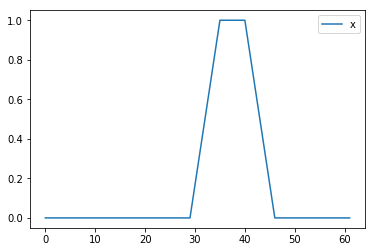

In [70]:
note = midi.Note(0, 'C', 2)

def pause(n):
    return [dict(midi=None) for _ in range(n)]

def with_t(sigs, fps=30):
    return [
        dict(t=i / fps, **{
            k: v for k, v in sig.items() if k != 't'
        })
        for i, sig in enumerate(sigs)
    ]

on = midi.Command(note, 'on')
off = midi.Command(note, 'off')
sigs = with_t(pause(30) + [{'midi': str(on)}] + pause(10) +  [{'midi': str(off)}] + pause(20))
d = dict(
    x=S.MidiPulse(note) | S.Lin(-5, 10) | S.Int(),
)
plot_sigs(d, sigs, ('x',))

# demo

In [5]:
# Demonstrate basic signals, signal runner.

class Add(L.Signal):
    def __init__(self, *signals):
        super().__init__(**{
            'sig{}'.format(i): name
            for i, name in enumerate(signals)
        })
        self.wants = signals
    def call(self, **kw):
        return sum([
            kw[name] for name in self.wants
        ])

class Mult(L.Signal):
    def __init__(self, factor):
        super().__init__(factor=factor)
    def call(self, value):
        return self.factor * value

signals = {
    'a': Add('b', 'c'),
    'b': L.Named('input') | Mult(1),
    'c': L.Named('input') | Mult(3),
    'abc': L.Named('a') * L.Named('b') * L.Named('c'),
}

runner = L.SignalRunner(signals, ('input',))
runner(input=1)

{'input': 1, 'b': 1, 'c': 3, 'a': 4, 'abc': 12}

Ramp(up_s=2,down_s=2) | Hyst(up_th=0.5,down_th=0.2) | Ramp(up_s=5,down_s=0.5) | Tocos()

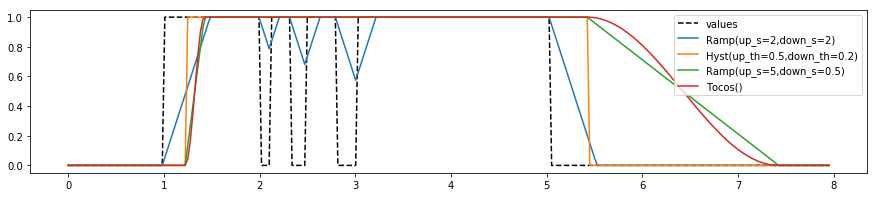

In [6]:
# Derive some simple state with noisy input.
# And plot chain's intermediate signals.

def piecewise(lengths, n):
    total = np.sum(lengths)
    length = 0
    values = []
    lengths.reverse()
    value = 1
    while len(values) < n:
        if length <= 0:
            length = lengths.pop()
            value = 1 - value
        values.append(value)
        length -= total / n
    return np.array(values)


sig = S.Ramp(up_s=2, down_s=2) | S.Hyst(up_th=0.5, down_th=0.2) | S.Ramp(up_s=5, down_s=0.5) | S.Tocos()

n = 300
pieces = [1, 1, 0.1, 0.2, 0.15, 0.3, 0.2, 2, 3]
ts = np.linspace(0, sum(pieces), n)
values = piecewise(pieces, n)

outputs = np.zeros((n, sig.nsigs))
for i, (t, value) in enumerate(zip(ts, values)):
    _ = sig(t=t, value=value)
    outputs[i, :] = list(map(lambda x: x.lastout.value, sig.recurse()))

plt.figure(figsize=(15, 3))
plt.plot(ts, values, 'k--', label='values')
for output, name in zip(outputs.T, sig.recurse()):
    plt.plot(ts, output, label=name)
plt.legend(loc='upper right')

sig

0.0 3.799670908927088 4.299670908927088 5.680836714587359 6.180836714587359
6.262626262626262 9.304529859290625 9.804529859290625 11.489666197584825 11.989666197584825


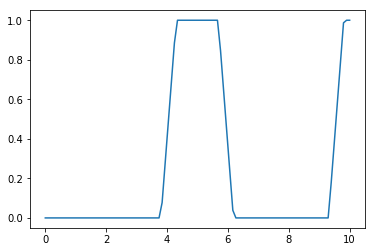

In [81]:
import random


def _rnd(minmax):
    return minmax[0] + random.random() * (
        minmax[1] - minmax[0])



class RndRamp(L.Signal):

    def init(self, break_minmax, duration_minmax, ramp_minmax=[0.5, 0.5]):
        self.break_minmax = break_minmax
        self.duration_minmax = duration_minmax
        self.ramp_minmax = ramp_minmax
        self.t3 = -1

    def call(self, t):
        if t > self.t3:
            self.t0 = t + _rnd(self.break_minmax)
            self.t1 = self.t0 + _rnd(self.ramp_minmax)
            self.t2 = self.t1 + _rnd(self.duration_minmax)
            self.t3 = self.t2 + _rnd(self.ramp_minmax)
            print(t, self.t0, self.t1, self.t2, self.t3)
        if t < self.t0:
            return 0.
        if t < self.t1:
            return (t - self.t0) / (self.t1 - self.t0)
        if t < self.t2:
            return 1.
        return 1 - (t - self.t2) / (self.t3 - self.t2)



x = RndRamp([3, 5], [1, 2])

ts = np.linspace(0, 10, 100)
plt.plot(ts, [x(t=t)['value'] for t in ts])

# better ?

some problems with original approach

- messy packages
- duplication
- not so well suited for animations
- dictionary inputs/outputs

improvement ideas

- optimized for readability
- smaller reusable functions
- arbitrary input/output (mostly scalars, ndarrays, or named tuples)
- good error messages


## def

## examples

# state

In [11]:
k, v = 'blh'.split('=')

ValueError: not enough values to unpack (expected 2, got 1)

In [9]:
s = state.State()
s.play('whatever')
s

state.State(str(s))

State(playing=whatever,state=std)

In [10]:
float('')

ValueError: could not convert string to float: 

In [115]:
class C:
    def __init__(self):
        self.i = 0
        self.x = -1
    def __getattr__(self, k):
        print('getattr', k, self.i)
        self.i += 1
        if self.i < 3:
            val = getattr(self, k)
        else:
            val = None
        self.i -= 1
        return val
    
c = C()
c.x

-1

In [11]:
# tmp

import time

class PrintEvery:
    def __init__(self, dt):
        self.dt = dt
        self.t0 = 0
    def __call__(self, msg):
        if time.time() - self.t0 > self.dt:
            self.t0 = time.time()
            print(msg)

x = PrintEvery(1.)
for i in range(10):
    time.sleep(0.2)
    x('blah')

blah
blah


In [12]:
1.5%1

0.5